## Quasi Periodic Eruptions – Plots

### Preamble

In [42]:
from svgpathtools import svg2paths
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extract_curve(svg_file_path):
    paths, attributes = svg2paths(svg_file_path)

    identifiers = ['#000000', 'rgb(0,0,0)', 'rgb(0, 0, 0)']

    points = []

    for path, attr in zip(paths, attributes):

        style_str = attr.get('style', '').lower()
        stroke_str = attr.get('stroke', '').lower()
        fill_str = attr.get('fill', '').lower()
        combined_attr = f'{style_str} {stroke_str} {fill_str}'

        black = any(color in combined_attr for color in identifiers)

        if not black:
            
            pts = []
            
            for segment in path:
                pts.append((segment.start.real, segment.start.imag))
            
            if path:
                pts.append((path[-1].end.real, path[-1].end.imag))

            points.extend(pts)

        def clean_data(point_list):
            
            if not point_list:
                return pd.DataFrame(columns=['x_svg', 'y_svg'])
        
            unique_points = list(dict.fromkeys(point_list))
            df = pd.DataFrame(unique_points, columns=['x_svg', 'y_svg'])
        
            return df

    df = clean_data(points)
    
    return df

def extract_exact_curves(svg_file_path):
    paths, attributes = svg2paths(svg_file_path)
    
    red_identifiers = ['#ff0000', 'rgb(255,0,0)', 'rgb(255, 0, 0)']
    blue_identifiers = ['#0000ff', 'rgb(0,0,255)', 'rgb(0, 0, 255)']
    
    red_points = []
    blue_points = []
    
    for path, attr in zip(paths, attributes):
        
        style_str = attr.get('style', '').lower()
        stroke_str = attr.get('stroke', '').lower()
        fill_str = attr.get('fill', '').lower()
        combined_attr = f"{style_str} {stroke_str} {fill_str}"
        
        is_red = any(color in combined_attr for color in red_identifiers)
        is_blue = any(color in combined_attr for color in blue_identifiers)
        
        if is_red or is_blue:
            points = []
            for segment in path:
                points.append((segment.start.real, segment.start.imag))
            
            if path:
                points.append((path[-1].end.real, path[-1].end.imag))
                
            if is_red:
                red_points.extend(points)
            if is_blue:
                blue_points.extend(points)

    def clean_data(point_list):
        if not point_list:
            return pd.DataFrame(columns=['x_svg', 'y_svg'])
        
        unique_points = list(dict.fromkeys(point_list))
        df = pd.DataFrame(unique_points, columns=['x_svg', 'y_svg'])
        
        return df

    df_red = clean_data(red_points)
    df_blue = clean_data(blue_points)
    
    return df_red, df_blue

def extract_axis_ticks(svg_file_path, max_tick_length=15):
    paths, attributes = svg2paths(svg_file_path)
    
    x_tick_coords = [] # Vertical lines indicating X positions
    y_tick_coords = [] # Horizontal lines indicating Y positions

    identifiers = ['#000000', 'rgb(0,0,0)', 'rgb(0, 0, 0)']
    
    for path, attr in zip(paths, attributes):

        style_str = attr.get('style', '').lower()
        stroke_str = attr.get('stroke', '').lower()
        fill_str = attr.get('fill', '').lower()
        combined_attr = f'{style_str} {stroke_str} {fill_str}'

        black = any(color in combined_attr for color in identifiers)

        if black:
            for segment in path:
                # Get start and end points
                x1, y1 = segment.start.real, segment.start.imag
                x2, y2 = segment.end.real, segment.end.imag
                
                dx = abs(x1 - x2)
                dy = abs(y1 - y2)
                length = (dx**2 + dy**2)**0.5
                
                # 1. Filter by length to ignore axes or data curves
                if 0 < length <= max_tick_length:
                    
                    # 2. Identify X-ticks: Vertical lines (constant x)
                    # We extract the x-coordinate where the tick occurs
                    if dx < 0.0001: # Tolerance for near-perfect vertical
                        x_tick_coords.append(x1)
                    
                    # 3. Identify Y-ticks: Horizontal lines (constant y)
                    # We extract the y-coordinate where the tick occurs
                    elif dy < 0.0001: # Tolerance for near-perfect horizontal
                        y_tick_coords.append(y1)

    def clean_ticks(coords, label):
        if not coords:
            return pd.DataFrame(columns=[label])
        
        # Sort and remove duplicates (ticks often have overlapping segments)
        df = pd.DataFrame(sorted(list(set(coords))), columns=[label])
        
#        # Invert Y if you want to match your curve cleaning logic
#        if label == 'y_svg':
#            df['y_svg'] = -df['y_svg']
            
        return df

    df_x_ticks = clean_ticks(x_tick_coords, 'x_svg')
    df_y_ticks = clean_ticks(y_tick_coords, 'y_svg')
    
    return df_x_ticks, df_y_ticks

def extract_major_ticks(svg_file_path):
    paths, attributes = svg2paths(svg_file_path)
    
    # Storage for (coordinate, length) tuples
    x_candidates = [] # [(x_val, length), ...]
    y_candidates = [] # [(y_val, length), ...]
    
    for path in paths:
        for segment in path:
            x1, y1 = segment.start.real, segment.start.imag
            x2, y2 = segment.end.real, segment.end.imag
            
            dx = abs(x1 - x2)
            dy = abs(y1 - y2)
            length = (dx**2 + dy**2)**0.5
            
            # Identify Vertical segments (X-axis ticks)
            if dx < 0.01 and length > 0.1:
                x_candidates.append((x1, length))
            
            # Identify Horizontal segments (Y-axis ticks)
            elif dy < 0.01 and length > 0.1:
                y_candidates.append((y1, length))

    def filter_major(candidates):
        if not candidates:
            return []
        
        # Find the maximum length in this set of candidates
        max_len = max(c[1] for c in candidates)
        
        # Filter: Only keep segments that match the maximum length
        # We use a small tolerance (0.1) in case of rendering offsets
        major_coords = [c[0] for c in candidates if abs(c[1] - max_len) < 0.1]
        
        # Deduplicate and sort
        return sorted(list(set(major_coords)))

    def clean_data(coords, label):
        df = pd.DataFrame(coords, columns=[label])
        if label == 'y_svg':
            df['y_svg'] = -df['y_svg']
        return df

    # Process and filter
    major_x = filter_major(x_candidates)
    major_y = filter_major(y_candidates)
    
    return clean_data(major_x, 'x_svg'), clean_data(major_y, 'y_svg')

### Read Vector Files

found 635 points

       x_svg      y_svg
0  14.262745  26.423109
1  14.364556  27.404650
2  14.466395  24.174355
3  14.568206  23.822758
4  14.670044  22.452996


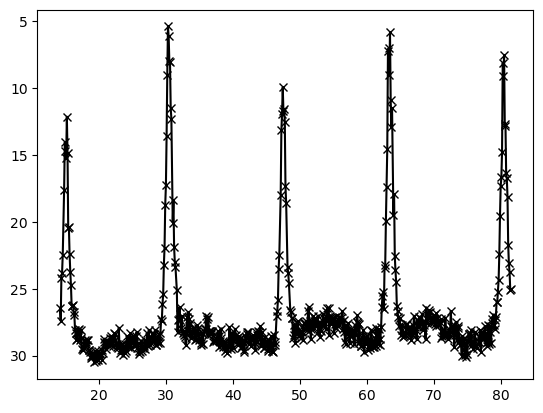

In [2]:
df = extract_curve('content/top/GSN-069.svg')
print(f'found {len(df)} points\n')
print(df.head())

x_sig_1 = np.array(df.sort_values(by='x_svg')['x_svg'])
y_sig_1 = np.array(df.sort_values(by='x_svg')['y_svg'])

plt.plot(x_sig_1, y_sig_1, 'kx-')
plt.gca().invert_yaxis()
plt.show()
plt.close()

found 170 points

       x_svg       y_svg
0  4988.8050  230.965450
1  5254.1198  230.965450
2  5254.1198  126.602100
3  4988.8050  126.602100
4   122.4000   97.199992


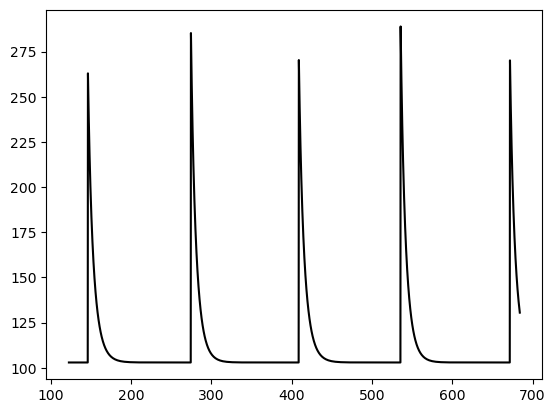

In [3]:
df = extract_curve('content/bot/GSN-069.svg')
print(f'found {len(df)} points\n')
print(df.head())

x_fit_1 = np.array(df.sort_values(by='x_svg')['x_svg'])
y_fit_1 = np.array(df.sort_values(by='x_svg')['y_svg'])

x_fit_1 = x_fit_1[y_fit_1 < 300]
y_fit_1 = y_fit_1[y_fit_1 < 300]
x_fit_1 = x_fit_1[y_fit_1 > 100]
y_fit_1 = y_fit_1[y_fit_1 > 100]
y_fit_1 = y_fit_1[x_fit_1 < 1000]
x_fit_1 = x_fit_1[x_fit_1 < 1000]

plt.plot(x_fit_1, y_fit_1, 'k-')
plt.show()
plt.close()

found 387 points

        x_svg       y_svg
0   23.001877   15.581984
1  695.489960   15.581984
2  695.489960  619.245310
3   23.001877  619.245310
4    0.000000    0.000000


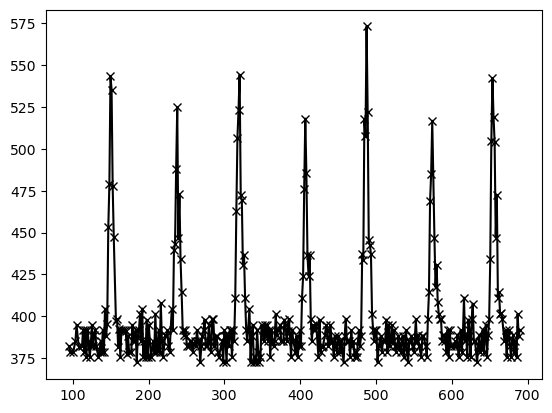

In [4]:
df = extract_curve('content/top/eRO-QPE2.svg')
print(f'found {len(df)} points\n')
print(df.head())

x_sig_2 = np.array(df.sort_values(by='x_svg')['x_svg'])
y_sig_2 = np.array(df.sort_values(by='x_svg')['y_svg'])

x_sig_2 = x_sig_2[y_sig_2 < 600]
y_sig_2 = y_sig_2[y_sig_2 < 600]
x_sig_2 = x_sig_2[y_sig_2 > 300]
y_sig_2 = y_sig_2[y_sig_2 > 300]

plt.plot(x_sig_2, y_sig_2, 'kx-')
plt.show()
plt.close()

found 235 points

        x_svg       y_svg
0   122.40007   97.200006
1   684.00007   97.200006
2   684.00007  318.109100
3   122.40007  318.109100
4  5756.27200  396.093320


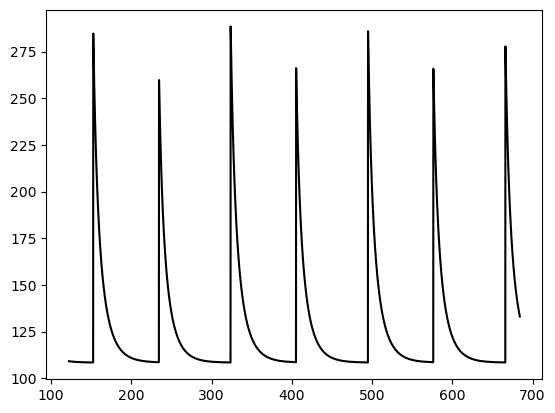

In [5]:
df = extract_curve('content/bot/eRO-QPE2.svg')
print(f'found {len(df)} points\n')
print(df.head())

x_fit_2 = np.array(df.sort_values(by='x_svg')['x_svg'])
y_fit_2 = np.array(df.sort_values(by='x_svg')['y_svg'])

x_fit_2 = x_fit_2[y_fit_2 < 300]
y_fit_2 = y_fit_2[y_fit_2 < 300]
x_fit_2 = x_fit_2[y_fit_2 > 100]
y_fit_2 = y_fit_2[y_fit_2 > 100]
y_fit_2 = y_fit_2[x_fit_2 < 1000]
x_fit_2 = x_fit_2[x_fit_2 < 1000]

plt.plot(x_fit_2, y_fit_2, 'k-')
plt.show()
plt.close()

found 461 points

        x_svg       y_svg
0   11.712505   17.831339
1  703.956880   17.831339
2  703.956880  618.672380
3   11.712505  618.672380
4  137.050440  432.482520


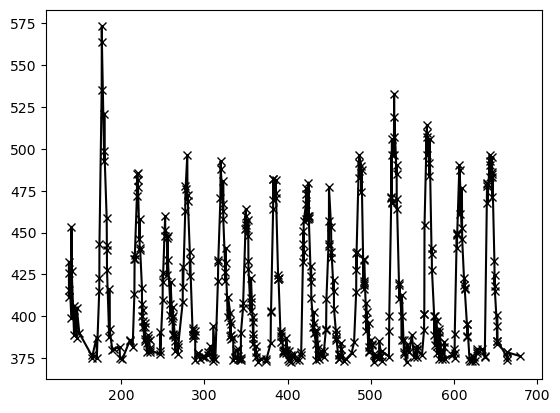

In [6]:
df = extract_curve('content/top/eRO-QPE1.svg')
print(f'found {len(df)} points\n')
print(df.head())

x_sig_3 = np.array(df.sort_values(by='x_svg')['x_svg'])
y_sig_3 = np.array(df.sort_values(by='x_svg')['y_svg'])

x_sig_3 = x_sig_3[y_sig_3 < 600]
y_sig_3 = y_sig_3[y_sig_3 < 600]
x_sig_3 = x_sig_3[y_sig_3 > 300]
y_sig_3 = y_sig_3[y_sig_3 > 300]

plt.plot(x_sig_3, y_sig_3, 'kx-')
plt.show()
plt.close()

found 391 points

        x_svg       y_svg
0   11.712505   17.831339
1  703.956880   17.831339
2  703.956880  618.672380
3   11.712505  618.672380
4    0.000000    0.000000


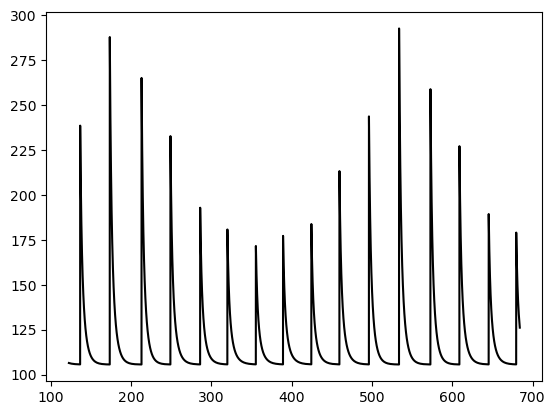

In [7]:
df = extract_curve('content/bot/eRO-QPE1.svg')
print(f'found {len(df)} points\n')
print(df.head())

x_fit_3 = np.array(df.sort_values(by='x_svg')['x_svg'])
y_fit_3 = np.array(df.sort_values(by='x_svg')['y_svg'])

x_fit_3 = x_fit_3[y_fit_3 < 300]
y_fit_3 = y_fit_3[y_fit_3 < 300]
x_fit_3 = x_fit_3[y_fit_3 > 100]
y_fit_3 = y_fit_3[y_fit_3 > 100]
y_fit_3 = y_fit_3[x_fit_3 < 1000]
x_fit_3 = x_fit_3[x_fit_3 < 1000]

plt.plot(x_fit_3, y_fit_3, 'k-')
plt.show()
plt.close()

found 466 points

        x_svg       y_svg
0   24.534178   12.759656
1  697.022470   12.759656
2  697.022470  622.067610
3   24.534178  622.067610
4  122.399950  362.290920


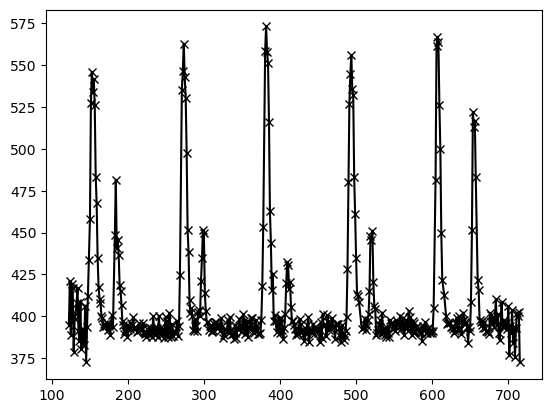

In [8]:
df = extract_curve('content/top/RX-J1302.svg')
print(f'found {len(df)} points\n')
print(df.head())

x_sig_4 = np.array(df.sort_values(by='x_svg')['x_svg'])
y_sig_4 = np.array(df.sort_values(by='x_svg')['y_svg'])

x_sig_4 = x_sig_4[y_sig_4 < 580]
y_sig_4 = y_sig_4[y_sig_4 < 580]
x_sig_4 = x_sig_4[y_sig_4 > 370]
y_sig_4 = y_sig_4[y_sig_4 > 370]

plt.plot(x_sig_4, y_sig_4, 'kx-')
plt.show()
plt.close()

found 253 points

          x_svg       y_svg
0  2.453418e+01   12.759656
1  6.970225e+02   12.759656
2  6.970225e+02  622.067610
3  2.453418e+01  622.067610
4 -2.000060e-07    0.000004


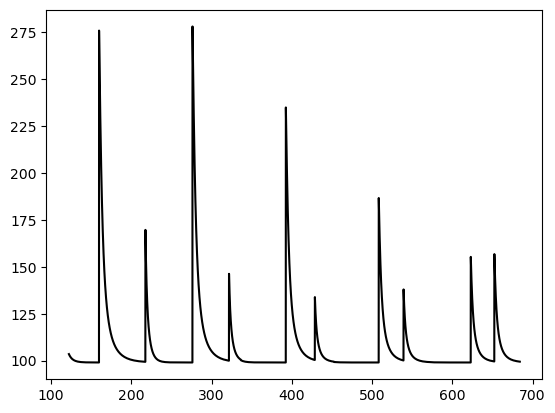

In [9]:
df = extract_curve('content/bot/RX-J1302.svg')
print(f'found {len(df)} points\n')
print(df.head())

x_fit_4 = np.array(df.sort_values(by='x_svg')['x_svg'])
y_fit_4 = np.array(df.sort_values(by='x_svg')['y_svg'])

x_fit_4 = x_fit_4[y_fit_4 < 300]
y_fit_4 = y_fit_4[y_fit_4 < 300]
x_fit_4 = x_fit_4[y_fit_4 > 90]
y_fit_4 = y_fit_4[y_fit_4 > 90]
y_fit_4 = y_fit_4[x_fit_4 < 1000]
x_fit_4 = x_fit_4[x_fit_4 < 1000]

plt.plot(x_fit_4, y_fit_4, 'k-')
plt.show()
plt.close()

### Scale Axes

found 19 xticks and 7 yticks

       x_svg
0  14.262745
1  17.928415
2  21.594111
3  25.259807
4  28.925477


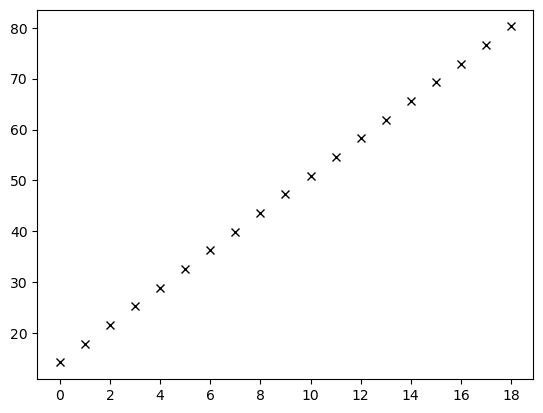

       y_svg
0   6.726361
1  10.388829
2  14.051295
3  17.713764
4  21.376230


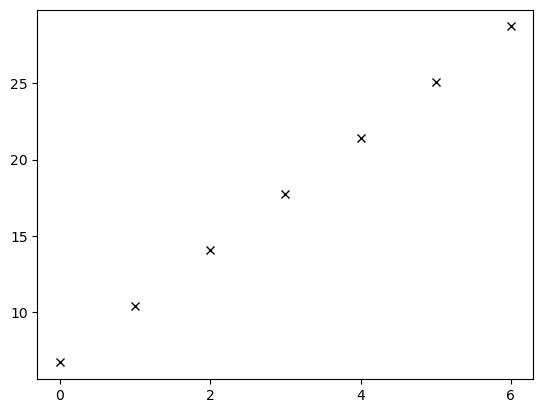

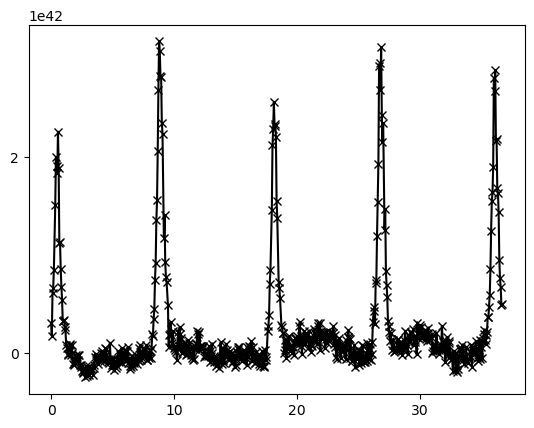

In [43]:
df_x, df_y = extract_axis_ticks('content/top/GSN-069.svg')
print(f'found {len(df_x)} xticks and {len(df_y)} yticks\n')

xt, yt = np.array(df_x['x_svg']), np.array(df_y['y_svg'])

print(df_x.head())

plt.plot(xt, 'kx')
plt.xticks(np.arange(0, len(df_x) + 1, 2))
plt.show()
plt.close()

print(df_y.head())

plt.plot(yt, 'kx')
plt.xticks(np.arange(0, len(df_y) + 1, 2))
plt.show()
plt.close()

corr_x_sig_1 = 0.0 + (x_sig_1 - xt[0]) * (0.0 - 10.0) / (xt[0] - xt[5])
corr_y_sig_1 = 1e42 * (3.0 + (y_sig_1 - yt[0]) * (3.0 - 2.0) / (yt[0] - yt[2]))

plt.plot(corr_x_sig_1, corr_y_sig_1, 'kx-')
plt.xticks(np.arange(0, 35, 10))
plt.yticks(1e42 * np.arange(0, 3, 2))
plt.show()
plt.close()

found 19 xticks and 7 yticks

       x_svg
0  4997.8105
1  5011.6650
2  5025.5196
3  5039.3742
4  5053.2287


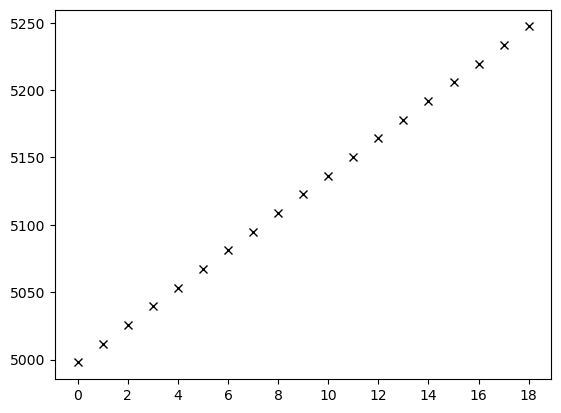

       y_svg
0  251.83811
1  268.78021
2  285.72231
3  302.66441
4  319.60652


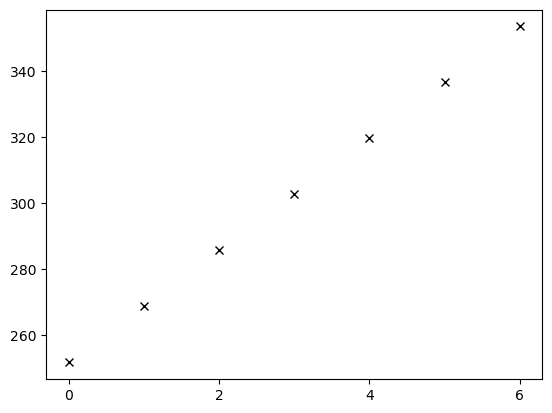

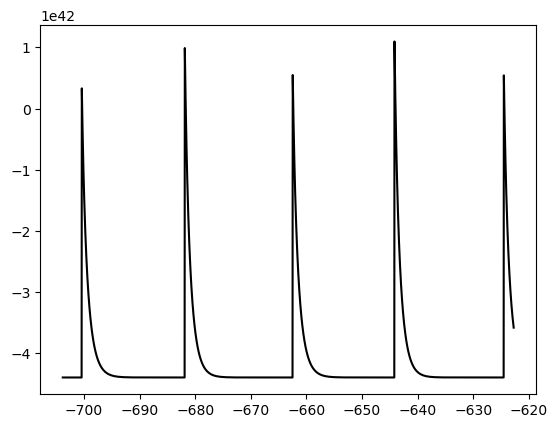

In [45]:
df_x, df_y = extract_axis_ticks('content/bot/GSN-069.svg')
print(f'found {len(df_x)} xticks and {len(df_y)} yticks\n')

xt, yt = np.array(df_x['x_svg']), np.array(df_y['y_svg'])

print(df_x.head())

plt.plot(xt, 'kx')
plt.xticks(np.arange(0, len(df_x) + 1, 2))
plt.show()
plt.close()

print(df_y.head())

plt.plot(yt, 'kx')
plt.xticks(np.arange(0, len(df_y) + 1, 2))
plt.show()
plt.close()

corr_x_fit_1 = 0.0 + (x_fit_1 - xt[0]) * (0.0 - 10.0) / (xt[0] - xt[5])
corr_y_fit_1 = 1e42 * (0.0 + (y_fit_1 - yt[0]) * (0.0 - 1.0) / (yt[0] - yt[2]))

plt.plot(corr_x_fit_1, corr_y_fit_1, 'k-')
#plt.xticks(np.arange(0, 35, 10))
#plt.yticks(1e42 * np.arange(0, 3, 2))
plt.show()
plt.close()

### Write Data

In [ ]:
with open('build/mu_präz_1.tex', 'w') as f:
	f.write(r'\qty{')
	f.write(f'{mu_präz_1.n:.3f}({mu_präz_1.s:.3f})')
	f.write(r'}{\ampere\meter\squared}')